Вспомогательный класс

In [5]:
from enum import Enum
from typing import Union, Generator
import os
import math
import io
import itertools

from immutable_views import *
import nbtlib
from nbtlib import File
from nbtlib.tag import *



class _VarintIO:
    ''''''

    ### --- Fields

    # Used for reading the int bits from a varint byte
    _INT_BITMASK =      0b0111_1111
    # Used for reading the continue bit in a byte, which is
    # the MSB, if one, we continue reading to the next byte.
    _CONTINUE_BITMASK = 0b1000_0000

    ### ---


    ### --- Public static methods

    '''
    Reads and returns the next varint of a varint byte stream while making it advance.
    Note that the varint read is going to be positive I was too lazy 
    '''
    @staticmethod
    def readPositiveVarInt(stream: io.BytesIO) -> int:
        # Setup
        varint: int = 0
        positionInInt: int = 0

        # Going while we didn't finish reading the int
        while True:
            # Read the next byte of the stream
            currentByte = int.from_bytes(stream.read(1), 'big', signed=False)
            # Add the int bits to our varint
            varint |= (currentByte & _VarintIO._INT_BITMASK) << positionInInt

            # If the continue bit is 0, then stop reading this int
            if (currentByte & _VarintIO._CONTINUE_BITMASK) == 0:
                break

            # If we are continuing, add 7 to the position in the int, since
            # in varints the int is separated in groups of 7 bits.
            positionInInt += 7

        return varint

def _initFromFile(schematicToLoadPath: str):
    # Get the schematic file as a nbt map
    schematicFile = nbtlib.load(schematicToLoadPath)
    fileBase = schematicFile['Schematic'] if 'Schematic' in schematicFile else schematicFile


    ## Init the block palette
    filePalette = fileBase['Palette']
    structureBlockPalette = {}

    for blockState, idTagInPalette in filePalette.items():
        idInPalette = int(idTagInPalette)
        structureBlockPalette[blockState] = idInPalette
        structureBlockPalette[idInPalette] = blockState
    # Nothing has been put inside the block palette, so we default init it.
    if len(structureBlockPalette) == 0:
        structureBlockPalette = {'minecraft:air': 0, 0: 'minecraft:air'}
    # Set the free Id to the length of the block palette // 2 as each Id has 2 entries
    structureBlockPaletteFreeId = (len(structureBlockPalette) // 2)

    # -- Re process the block palette so that ID 0 is air
    # Put air inside the hashmap if it wasn't present yet.
    # used for future processing that's why it's not equal to 0
    if 'minecraft:air' not in structureBlockPalette:
        structureBlockPalette['minecraft:air'] = structureBlockPaletteFreeId
        structureBlockPalette[structureBlockPaletteFreeId] = 'minecraft:air'
        structureBlockPaletteFreeId += 1
    # If the current air ID isn't 0, switch it up with the
    # current 0 id, example:
    #   palette{0: black_wool, 1: air} will get switched to:
    #   palette{0: air, 1: black_wool}
    # And the byte ids will get processed afterwards
    beforeProcessingAirId = structureBlockPalette['minecraft:air']
    airOldId = beforeProcessingAirId
    if beforeProcessingAirId != 0:
        beforeProcessingId0State = structureBlockPalette[0]
        # Pop the 0 id
        structureBlockPalette.pop(0)
        structureBlockPalette.pop(beforeProcessingId0State)
        # Pop the air id
        structureBlockPalette.pop(beforeProcessingAirId)
        structureBlockPalette.pop('minecraft:air')

        # Put the air at 0
        structureBlockPalette[0] = 'minecraft:air'
        structureBlockPalette['minecraft:air'] = 0
        # Put the old currentId0State where air was
        structureBlockPalette[beforeProcessingAirId] = beforeProcessingId0State
        structureBlockPalette[beforeProcessingId0State] = beforeProcessingAirId


    ## Init the blockStates in _blockStates
    structureBlockStates: dict[tuple[int, int, int], int] = {}
    if 'BlockData' in fileBase:

        # Get the necessary data for blockState loading
        fileBlockStatesIds = fileBase['BlockData']
        blockStatesIds = bytearray(fileBlockStatesIds)
        schemOffset = (0, 0, 0)# fileBase['Offset']
        schemHeight = int(fileBase['Height'])  # y
        schemLength = int(fileBase['Length'])  # z
        schemWidth = int(fileBase['Width'])  # x

        # Variable so that we don't have to do a multiplication every iteration
        schemYSliceArea = schemWidth * schemLength


        if len(structureBlockPalette) < 128:
            # The amount of block states is less than 128, so each block is a byte,
            # so we use the old faster algorithm to load the structure

            for blockStateIndex, blockStateId in enumerate(blockStatesIds):
                # Process the blockStateId since the palette has been modified
                processedBlockStateId = blockStateId
                # -- Do le switcharoo, air new Id is 0 no matter what
                # If we refer to the old air Id, it means that we refer to air now
                # which is 0
                if blockStateId == airOldId:
                    processedBlockStateId = 0
                # If we refer to the old id at 0, we are referring to the new
                # content of the old air id spot
                if blockStateId == 0:
                    processedBlockStateId = airOldId

                # Since we processed the blockPalette so that air is 0, if the ID is 0
                # then skip, as we don't keep track of air blocks

                # Getting the coordinates in the schem not shifted yet
                blockStateSchemY = blockStateIndex // schemYSliceArea
                blockStateSchemZ = ( blockStateIndex % schemYSliceArea ) // schemWidth
                blockStateSchemX = blockStateIndex % schemWidth

                # Shift the coordinates so that the blocks are back in their right position
                realY = blockStateSchemY + schemOffset[1]
                realZ = blockStateSchemZ + schemOffset[2]
                realX = blockStateSchemX + schemOffset[0]

                # Place the block
                structureBlockStates[(realX, realY, realZ)] = processedBlockStateId

        else:
            # The palette contains more (or equal) than 128 entries, so we use
            # the varint algorithm

            # Put the blockState bytes into a BytesIO for a stream
            blockStatesIdStream = io.BytesIO(blockStatesIds)

            # Setup before loopin woo
            blockStateIndex = 0

            # We loopin bois
            while blockStatesIdStream.tell() < len(blockStatesIds):
                # Get the next varint of the stream
                blockStateId = _VarintIO.readPositiveVarInt(blockStatesIdStream)
                # From there, use the normal old algorithm, cba to put it in
                # a method lmfao

                # ===
                # Process the blockStateId since the palette has been modified
                processedBlockStateId = blockStateId
                # -- Do le switcharoo, air new Id is 0 no matter what
                # If we refer to the old air Id, it means that we refer to air now
                # which is 0
                if blockStateId == airOldId:
                    processedBlockStateId = 0
                # If we refer to the old id at 0, we are referring to the new
                # content of the old air id spot
                if blockStateId == 0:
                    processedBlockStateId = airOldId

                # Since we processed the blockPalette so that air is 0, if the ID is 0
                # then skip, as we don't keep track of air blocks

                # Getting the coordinates in the schem not shifted yet
                blockStateSchemY = blockStateIndex // schemYSliceArea
                blockStateSchemZ = (blockStateIndex % schemYSliceArea) // schemWidth
                blockStateSchemX = blockStateIndex % schemWidth

                # Shift the coordinates so that the blocks are back in their right position
                realY = blockStateSchemY + schemOffset[1]
                realZ = blockStateSchemZ + schemOffset[2]
                realX = blockStateSchemX + schemOffset[0]

                # Place the block
                structureBlockStates[(realX, realY, realZ)] = processedBlockStateId
                # ===

                # -- Increment block state index as we're done registering that block
                blockStateIndex += 1
    
    return structureBlockStates, structureBlockPalette


In [7]:
import json

# INFESTED = "minecraft:infested_"
AIR = "minecraft:air"
# WATER = "minecraft:water"
# BLOCK_TYPE = "block_type"
AIR_BLOCK_IDX = 0

with open("../block_data/filtered_blocks.json") as f:
    filtered_blocks_dict = json.load(f)
    idx2block = sorted(list(filtered_blocks_dict.keys()))
    air_idx = idx2block.index(AIR)
    idx2block[AIR_BLOCK_IDX], idx2block[air_idx] = idx2block[air_idx], idx2block[AIR_BLOCK_IDX]
    block2idx = {idx2block[i]: i for i in range(len(idx2block))}
    with open("../block_data/idx2block.json", "w") as w:
        json.dump(idx2block, w, indent=4)
    with open("../block_data/block2idx.json", "w") as w:
        json.dump(block2idx, w, indent=4)

Код для парсинга схематик в папке в тензоры

In [ ]:
import nbtlib
import os
import json
from pathlib import Path
from tqdm import tqdm
import numpy as np

INFESTED = "minecraft:infested_"
AIR = "minecraft:air"
BLOCK_TYPE_TENSORS = "block_type_tensors"
ATTRIBUTES_DATA = "attributes_data"


def parse_block(block: str):
    """
    block : str
        A string representing minecraft block with its attributes.
        Example: minecraft:water[level=0]
    """
    idx = block.find("[")
    if idx != - 1:
        block, attr_data = block[:idx], block[idx + 1: -1]
    else:
        return block, {}

    
    attr_data = attr_data.split(",")
    attr_dict = {}
    for item in attr_data:
        attr, value = item.split("=")
        attr_dict[attr] = value
    return block, attr_dict


def filter_attribute_dict(
        block: str,
        attr_dict: dict[str, str],
        attributes_defaults: dict[str, str],
        block_attributes_defaults: dict[str, dict[str, str]],
        filtered_blocks_dict: dict[str, dict[str, list[str]]]
    ) -> dict[str, int]:
    """
    block : str
        A string representing the type of block
    attr_dict : dict
        A dict representing the attribute data of this block
    attributes_defaults : dict
        A dict of default attributes for all blocks
    block_attributes_defaults : dict
        A dict of default attributes for specific blocks
    filtered_blocks_dict : dict
        A dict containg an attribute dict with the values spectre for each block

    Returns : dict[str, int]
        A filtered attr dict without defaults and with indexes
    """
    final_attr_dict = {}
    for attr in attr_dict:
        if attr not in attributes_defaults:
            if block in block_attributes_defaults:
                if attr not in block_attributes_defaults[block]:
                    final_attr_dict[attr] = attr_dict[attr]
            else:
                final_attr_dict[attr] = attr_dict[attr]

    for attr in final_attr_dict:
        value = final_attr_dict[attr]
        block_attrs = filtered_blocks_dict[block]
        final_attr_dict[attr] = block_attrs[attr].index(value)

    return final_attr_dict

def block_to_idx(block: str, block2idx: dict[str, int]) -> int:
    """
    A function that matches the block type and its index,
    considering filtered blocks. Infested blocks are treated
    as their normal variant. Other filtered blocks are treated
    as air blocks.
    
    Args:

    block : str
        A string representing minecraft block type (ex. 'minecraft:stone')
    block2idx : dict
        A dict for matching block type and its index
    """

    if block not in block2idx:
        if block.startswith(INFESTED):
            block = "minecraft:" + block[len(INFESTED):]
        else:
            block = AIR
    return block, block2idx[block]


def parse_schematics(data_dir, output_dir=None):
    """
    A function for turning schematics in folder into tensors
    """
    if output_dir is None:
        output_dir = data_dir
    output_dir = Path(output_dir)

    os.makedirs(output_dir / BLOCK_TYPE_TENSORS, exist_ok=True)
    os.makedirs(output_dir / ATTRIBUTES_DATA, exist_ok=True)

    with open("filtered_blocks.json") as f:
        filtered_blocks_dict = json.load(f)
        idx2block = sorted(list(filtered_blocks_dict.keys()))
        block2idx = {idx2block[i]: i for i in range(len(idx2block))}
    with open("attributes_defaults.json") as f:
        attributes_defaults = json.load(f)
    with open("block_attributes_defaults.json") as f:
        block_attributes_defaults = json.load(f)
    
    for file in tqdm(sorted(os.listdir(data_dir))):
        file: Path = data_dir / file
        if file.suffix == ".schem":
            name = file.stem

            schem = nbtlib.load(file)
            length, width, height = schem["Length"], schem["Width"], schem["Height"]
            del schem

            coord2byte, palette  = _initFromFile(file)
            
            block_grid_tensor = np.zeros((width, height, length), dtype=np.int16) # x, y, z
            attributes = {}
            
            for x, y, z in coord2byte:            
                block_byte = coord2byte[(x,y,z)]
                block = palette[block_byte]

                block, attr_dict = parse_block(block) # str, dict
                block, block_idx= block_to_idx(block, block2idx) # str, int
                if block == AIR:
                    attr_dict = {}
            
                attr_dict = filter_attribute_dict(
                    block=block,
                    attr_dict=attr_dict,
                    attributes_defaults=attributes_defaults,
                    block_attributes_defaults=block_attributes_defaults,
                    filtered_blocks_dict=filtered_blocks_dict
                )

                block_grid_tensor[x][y][z] = block_idx
                if len(attr_dict):
                    attributes[f"{x}_{y}_{z}"] = attr_dict
            np.save(output_dir / BLOCK_TYPE_TENSORS / name, block_grid_tensor)
            with open(output_dir / ATTRIBUTES_DATA / f"{name}.json", "w") as f:
                json.dump(attributes, f, indent=4)


In [3]:
data_dir = Path("./test_chunky_schematics")
parse_schematics(data_dir)

100%|██████████| 101/101 [00:16<00:00,  6.13it/s]


Код для получения цветов для каждого блока (и ещё имя соотвествующей текстуры)

In [21]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import editdistance
from tqdm import tqdm
import json

WATER = "minecraft:water"
LAVA = "minecraft:lava"

def get_colors(texture_folder_path: str):
    with open("filtered_blocks.json") as f:
        filtered_blocks_dict = json.load(f)
        idx2block = sorted(list(filtered_blocks_dict.keys()))
        block2idx = {idx2block[i]: i for i in range(len(idx2block))}
    texture_folder_path = Path(texture_folder_path)

    block2color = {}

    block2texture = {}

    for raw_block in tqdm(block2idx, desc="Finding textures and colors for blocks"):
        block: str = raw_block[raw_block.index(":") + 1:]
        if block.endswith("leaves"):
            block2color[raw_block] = [39, 159, 20]
            continue
        if raw_block == AIR:
            block2color[raw_block] = [255,255,255]
            continue
        if raw_block == WATER:
            block2color[raw_block] = [0,128,255]
            continue
        if raw_block == LAVA:
            block2color[raw_block] = [255,69,0]
            continue
        min_dist = 1e10
        block_texture_file = ""
        for file in os.listdir(texture_folder_path):
            file = texture_folder_path / file
            dist = editdistance.eval(file.stem, block)

            if dist < min_dist:
                block_texture_file = file
                min_dist = dist
        block2texture[raw_block] = block_texture_file.stem
        texture = Image.open(block_texture_file)
        arr = np.array(texture)
        if len(arr.shape) < 3:
            block2color[raw_block] = [255, 0, 0]
            continue
        if arr.shape[-1] == 4:
            mask = np.array(texture)[:, :, 3] > 0
            arr = np.array(texture.convert("RGB"))
            arr = arr[mask]
        
        block2color[raw_block] = [int(arr[..., i].mean()) for i in range(3)]
    
    with open("block2color.json", "w") as f:
        json.dump(block2color, f, indent=4)

    with open("block2texture.json", "w") as f:
        json.dump(block2texture, f, indent=4)


Запустить 1 раз и больше не надо будет

In [22]:
get_colors("./1.20.1/assets/minecraft/textures/block")


Finding textures and colors for blocks: 100%|██████████| 975/975 [00:06<00:00, 142.58it/s]


Код для отрисовки куба на заданной позиции в 3D

In [111]:
import numpy as np
import plotly.graph_objects as go


def add_point_to_fig(fig: go.Figure, coords: tuple, color: tuple):
    x, y, z = coords
    fig.add_trace(
        go.Scatter3d(
            x=[x],
            y=[y],
            z=[z],
            mode='markers',
            marker=dict(
                size=1,
                color=color,
            ),
            showlegend=False,
        )
    )
    return fig
        


def add_cube_to_fig(fig: go.Figure, coords: tuple, color: tuple, show_edges=True):
    x, y, z = coords
    color = f"rgb{color}"

    vertices = np.array([
        [x - 0.5, y - 0.5, z - 0.5],  # 0
        [x + 0.5, y - 0.5, z - 0.5],  # 1
        [x + 0.5, y + 0.5, z - 0.5],  # 2
        [x - 0.5, y + 0.5, z - 0.5],  # 3
        [x - 0.5, y - 0.5, z + 0.5],  # 4
        [x + 0.5, y - 0.5, z + 0.5],  # 5
        [x + 0.5, y + 0.5, z + 0.5],  # 6
        [x - 0.5, y + 0.5, z + 0.5]   # 7
    ])

    faces = {
        'нижняя': [0, 1, 2, 3],
        'верхняя': [4, 5, 6, 7],
        'задняя': [0, 1, 5, 4],
        'передняя': [3, 2, 6, 7],
        'левая': [0, 3, 7, 4],
        'правая': [1, 2, 6, 5]
    }

    for _, face_indices in faces.items():
        # Берем 4 вершины грани
        face_vertices = vertices[face_indices]
        
        # Разбиваем квадратную грань на 2 треугольника
        # Треугольник 1: вершины 0, 1, 2
        # Треугольник 2: вершины 0, 2, 3
        i = [0, 0]
        j = [1, 2]
        k = [2, 3]
        
        fig.add_trace(go.Mesh3d(
            x=face_vertices[:, 0],
            y=face_vertices[:, 1],
            z=face_vertices[:, 2],
            i=i,
            j=j,
            k=k,
            color=color,
            flatshading=True,
            showlegend=False
        ))
    
    if show_edges:
        edges = [
            (0, 1), (1, 2), (2, 3), (3, 0),
            (4, 5), (5, 6), (6, 7), (7, 4),
            (0, 4), (1, 5), (2, 6), (3, 7)
        ]
        
        for edge in edges:
            start, end = edge
            fig.add_trace(go.Scatter3d(
                x=[vertices[start][0], vertices[end][0]],
                y=[vertices[start][1], vertices[end][1]],
                z=[vertices[start][2], vertices[end][2]],
                mode='lines',
                line=dict(color='black', width=2),
                showlegend=False
            ))

    return fig


def create_fig():
    fig = go.Figure()

    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
        ),
        width=800,
        height=600
    )
    
    return fig


Тестируем отрисовываем 2 куба

In [112]:
# Тестируем все методы
fig = create_fig()
fig = add_cube_to_fig(fig, (0.5, 0.5, 0.5), (198,45,123)) 
fig = add_cube_to_fig(fig, (0.5, 1.5, 0.5), (3,123,45)) 
fig.show()

Отрисовка схематики (только видимые блоки)

In [ ]:
import os
import json
from pathlib import Path

AIR = "minecraft:air"


def is_air_nearby_schem(coords, coord2byte, palette):
    for i in range(0, 1):
        for j in range(3):
            diff = 2 * i - 1 # -1 or 1
            neigh_coords = list(coords)
            neigh_coords[j] += diff
            neigh_coords = tuple(neigh_coords)

            if neigh_coords in coord2byte:
                block = palette[coord2byte[neigh_coords]]
                block, _ = parse_block(block) # to get only block type
                if block == AIR:
                    return True
    return False


def is_air_nearby_array(coords, array, idx2block):
    for i in range(0, 1):
        for j in range(3):
            diff = 2 * i - 1 # -1 or 1
            neigh_coords = list(coords)
            neigh_coords[j] += diff
            neigh_coords = tuple(neigh_coords)
            if 0 <= neigh_coords[j] < array.shape[j]:
                block_idx = array[neigh_coords[0], neigh_coords[1], neigh_coords[2]]
                if idx2block[block_idx] == AIR:
                    return True
    return False

def render_schematic(path):
    "Either path to .schem or .npy file"
    path = Path(path)
    coord2color = {} # coords to color without air blocks
    with open("block2color.json") as f:
        block2color = json.load(f)
        
    if path.suffix == ".schem":
        coord2byte, palette  = _initFromFile(path)
        for coords, byte in coord2byte.items():
            block = palette[byte]
            block, _ = parse_block(block) # to get only block type
            if block != AIR:
                if is_air_nearby_schem(coords, coord2byte, palette):
                    coord2color[coords] = block2color[block]
    elif path.suffix == ".npy":
        array = np.load(path)
        with open("filtered_blocks.json") as f:
            filtered_blocks_dict = json.load(f)
            idx2block = sorted(list(filtered_blocks_dict.keys()))
        
        for x in array.shape[0]:
            for y in array.shape[1]:
                for z in array.shape[2]:
                    block_idx = array[x, y, z]
                    block = idx2block[block_idx]
                    coords = (x, y, z)
                    if block != AIR:
                        if is_air_nearby_array(coords, array, idx2block):
                            coord2color[coords] = block2color[block]
    else:
        raise RuntimeError
            
    fig = create_fig()

    for coords, color in tqdm(coord2color.items(), desc="Rendering all visible blocks..."):
        fig = add_cube_to_fig(fig, coords, tuple(color))

    return fig
    

Тестируем и сохраняем, но рендериться будет чересчур долго

In [ ]:
fig = render_schematic("./test_chunky_schematics/5_-868_-822_66_135_813_835.schem")
fig.write_html("rendered.html")

In [ ]:
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
import nbtlib

AIR = "minecraft:air"

def add_image_to_axis(ax, img, title, x_label, y_label):
    ax.imshow(img, origin="lower")
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)


def render_2d_schematic(path, gradient=0):
    "Either path to .schem or .pt file"
    path = Path(path)
    with open("block2color.json") as f:
        block2color = json.load(f)
        
    if path.suffix == ".schem":
        fig, ax = plt.subplots(2, 3, figsize = (15, 10))

        schem = nbtlib.load(path)
        length, width, height = schem["Length"], schem["Width"], schem["Height"]
        del schem

        coord2byte, palette  = _initFromFile(path)

        # TOP and BOTTOM
        top_view = np.zeros((length, width, 3), dtype=np.int32)
        bottom_view = np.zeros((length, width, 3), dtype=np.int32)

        for x in range(width):
            for z in range(length):
                highest_block = AIR
                for y in range(height-1, -1, -1):
                    block = palette[coord2byte[(x, y, z)]]
                    block, _ = parse_block(block)
                    if block != AIR:
                        highest_block = block
                        break
                color = block2color[highest_block]
                top_view[z, x] = np.int32(np.maximum(0, np.array(color) - y * gradient))

                lowest_block = AIR
                for y in range(height):
                    block = palette[coord2byte[(x, y, z)]]
                    block, _ = parse_block(block)
                    if block != AIR:
                        lowest_block = block
                        break
                color = block2color[lowest_block]
                bottom_view[z, x] = np.int32(np.maximum(0, np.array(color) - y * gradient))

        # FRONT and BACK
        front_view = np.zeros((height, length, 3), dtype=np.int32)
        back_view = np.zeros((height, length, 3), dtype=np.int32)

        for y in range(height):
            for z in range(length):
                back_block = AIR
                for x in range(width-1, -1, -1):
                    block = palette[coord2byte[(x, y, z)]]
                    block, _ = parse_block(block)
                    if block != AIR:
                        back_block = block
                        break
                color = block2color[back_block]
                back_view[y, z] = np.int32(np.maximum(0, np.array(color) - y * gradient))

                front_block = AIR
                for x in range(width):
                    block = palette[coord2byte[(x, y, z)]]
                    block, _ = parse_block(block)
                    if block != AIR:
                        front_block = block
                        break
                color = block2color[front_block]
                front_view[y, z] = np.int32(np.maximum(0, np.array(color) - y * gradient))

        # RIGHT and LEFT
        right_view = np.zeros((height, width, 3), dtype=np.int32)
        left_view = np.zeros((height, width, 3), dtype=np.int32)

        for y in range(height):
            for x in range(width):
                left_block = AIR
                for z in range(length-1, -1, -1):
                    block = palette[coord2byte[(x, y, z)]]
                    block, _ = parse_block(block)
                    if block != AIR:
                        left_block = block
                        break
                color = block2color[left_block]
                left_view[y, x] = np.int32(np.maximum(0, np.array(color) - y * gradient))

                right_block = AIR
                for z in range(length):
                    block = palette[coord2byte[(x, y, z)]]
                    block, _ = parse_block(block)
                    if block != AIR:
                        right_block = block
                        break
                color = block2color[right_block]
                right_view[y, x] = np.int32(np.maximum(0, np.array(color) - y * gradient))

        add_image_to_axis(ax[0][0], top_view, "Top (-y)", "x", "z")
        add_image_to_axis(ax[1][0], bottom_view, "Bottom (+y)", "x", "z")

        add_image_to_axis(ax[0][1], back_view, "Back (-x)", "z", "y")
        add_image_to_axis(ax[1][1], front_view, "Front (+x)", "z", "y")

        add_image_to_axis(ax[0][2], left_view, "Left (-z)", "x", "y")
        add_image_to_axis(ax[1][2], right_view, "Right (+z)", "x", "y")

        return plt.show()
    else:
        raise RuntimeError
            

    

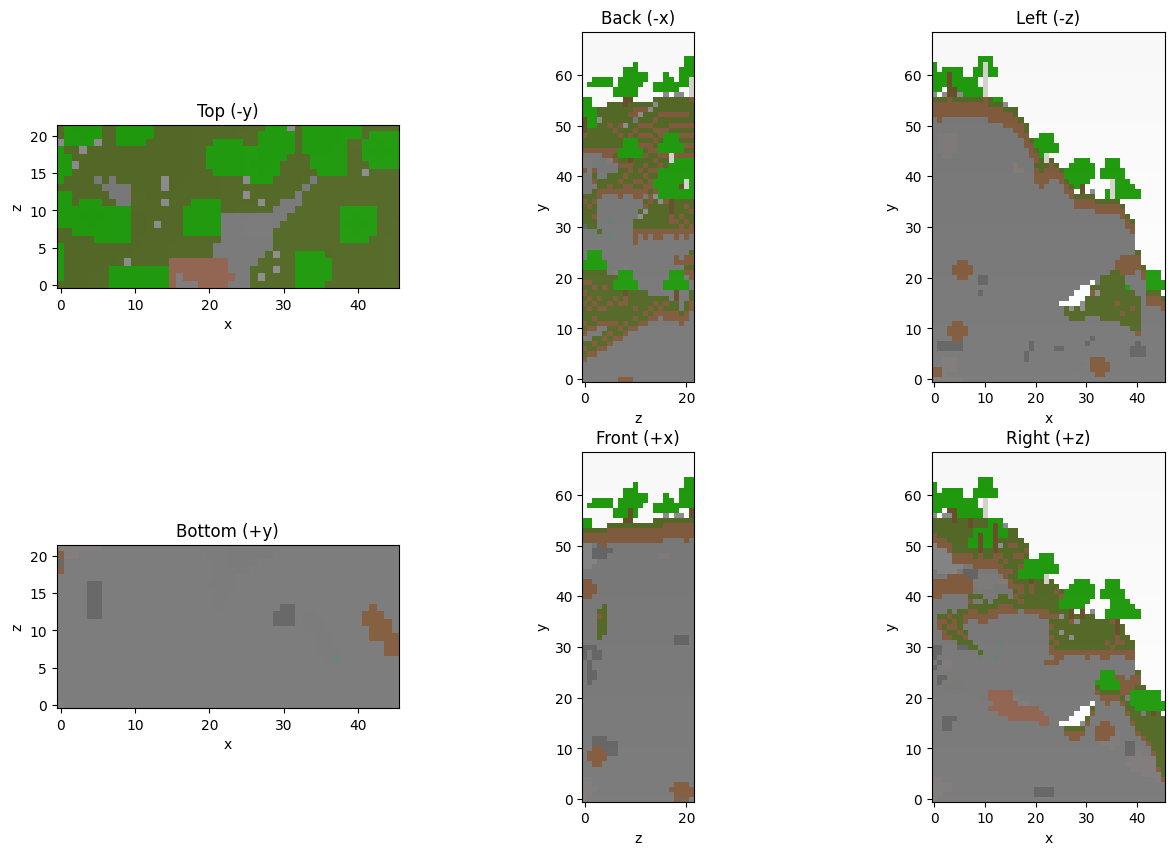

In [19]:
render_2d_schematic("./test_chunky_schematics/5_-868_-822_66_135_813_835.schem", gradient=0.1);

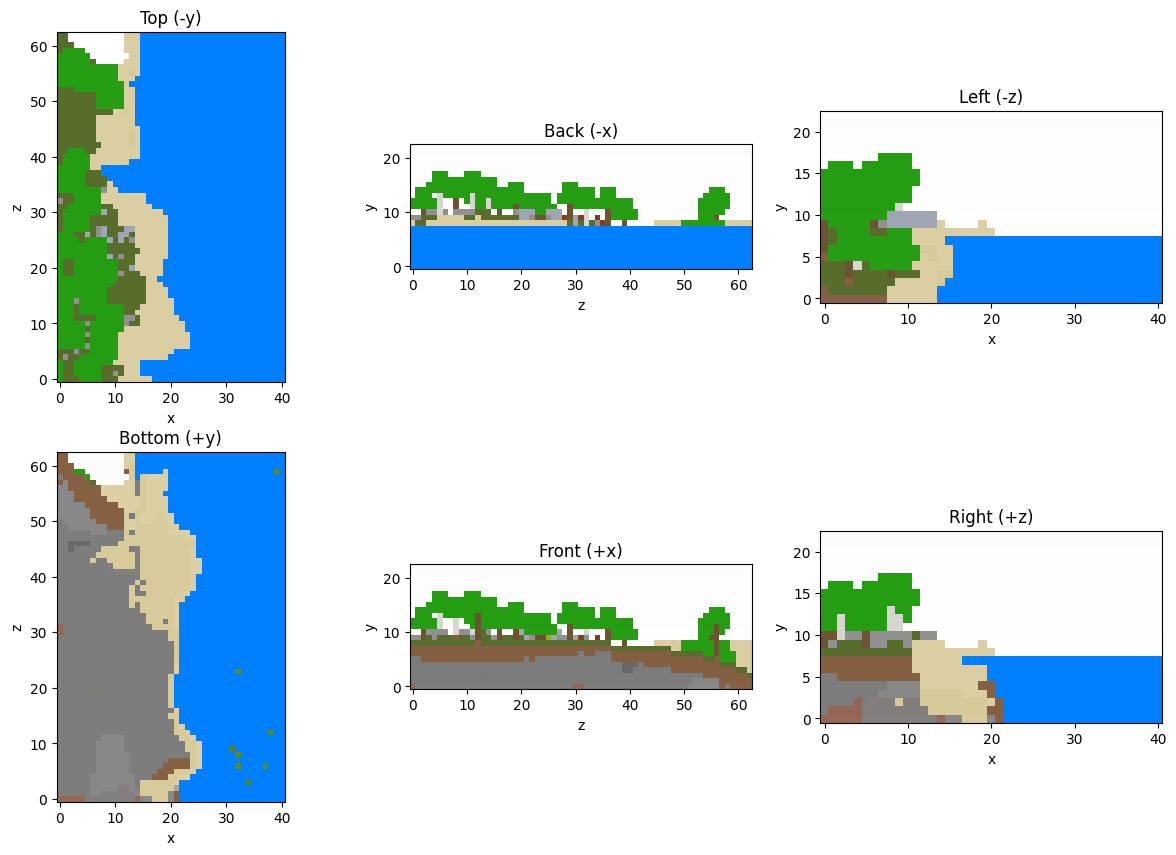

In [23]:
render_2d_schematic("./test_chunky_schematics/13_-419_-378_55_78_102_165.schem", gradient=0.1);